# Main sign reversal

Per-pair Spearman correlations between IRT difficulty and trajectory geometry
(directness, curvature, intrinsic dimensionality) before and after correcting for
generation length. Produces the hero sign-reversal figure and its dimensionality
companion.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 120,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

When `IRT_RESULTS_ROOT` points at a populated `data/results/` tree, the cells
below regenerate `data/processed/02_*.parquet` from per-model
`trajectory_summaries.parquet`. Otherwise they fall back to the shipped cache.


In [2]:
# >>> generation-marker <<<
RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('trajectories/trajectory_summaries.parquet'))
print(f'regenerate from raw? {REGEN}  (IRT_RESULTS_ROOT={RESULTS})')


regenerate from raw? False  (IRT_RESULTS_ROOT=data/results)


### Aggregate per-model trajectory data and difficulty lookup


In [3]:
# Aggregate per-model trajectory_summaries.parquet for the 11 hidden-state models.
# Following the paper's main figures, each correlation is computed PER sampled layer
# and the MEDIAN ACROSS the 5 layers is reported (more stable than a single 'peak'
# layer, especially for the near-zero / weak-signal cells).
HIDDEN_STATE_MODELS = REASONING_ORDER + BASELINE_ORDER  # 11 models
ROLE = {m: 'r1' for m in REASONING_ORDER} | {m: 'base' for m in BASELINE_ORDER}

import numpy as np
from scipy.stats import spearmanr, pearsonr

def _residualise(y, x):
    """Return y minus its OLS projection onto [1, x]."""
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

def _boot_ci(values_a, values_b, statistic, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(values_a)
    samples = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        samples.append(statistic(values_a[idx], values_b[idx]))
    samples = np.array(samples)
    lo, hi = np.quantile(samples, [(1 - ci) / 2, 1 - (1 - ci) / 2])
    return float(lo), float(hi)


def _median_layer_corr(df, dom, col, n_boot=1000, ci=0.95, seed=42):
    """Median-across-layers rho_raw / rho_perp (+ bootstrap CIs) for one metric column.

    Per layer: average runs to one row per problem, map IRT difficulty, then compute
    rho_raw = spearman(metric, difficulty) and rho_perp = spearman(metric residualised
    on log N, difficulty). The reported value is the median of these across the sampled
    layers. The bootstrap resamples problems (a shared resample applied to every layer)
    and re-medians, giving a CI for the median estimator.
    Returns (rho_raw, raw_lo, raw_hi, rho_perp, perp_lo, perp_hi, n_problems).
    """
    layers = sorted(df['layer'].unique())
    per_layer = {}
    for L in layers:
        a = (df[df['layer'] == L]
             .groupby('problem_id')
             .agg(y=(col, 'mean'), n=('n_tokens', 'mean')))
        a['d'] = [diff_map.get((dom, pid), np.nan) for pid in a.index]
        per_layer[L] = a.dropna()
    common = sorted(set.intersection(*[set(a.index) for a in per_layer.values()])) if per_layer else []
    if len(common) < 10:
        return (np.nan,) * 6 + (0,)
    Y = {L: per_layer[L].loc[common, 'y'].to_numpy(float) for L in layers}
    LN = {L: np.log(per_layer[L].loc[common, 'n'].to_numpy(float)) for L in layers}
    D = per_layer[layers[0]].loc[common, 'd'].to_numpy(float)

    def _stat(idx):
        d = D[idx]
        raws = [spearmanr(Y[L][idx], d)[0] for L in layers]
        perps = [spearmanr(_residualise(Y[L][idx], LN[L][idx]), d)[0] for L in layers]
        return float(np.median(raws)), float(np.median(perps))

    n = len(common)
    rho_raw, rho_perp = _stat(np.arange(n))
    rng = np.random.default_rng(seed)
    braw, bperp = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        r, p = _stat(idx)
        braw.append(r); bperp.append(p)
    q = [(1 - ci) / 2, 1 - (1 - ci) / 2]
    raw_lo, raw_hi = np.quantile(braw, q)
    perp_lo, perp_hi = np.quantile(bperp, q)
    return rho_raw, float(raw_lo), float(raw_hi), rho_perp, float(perp_lo), float(perp_hi), n

if REGEN:
    diffs = pd.read_parquet(PROCESSED / '01_difficulties.parquet').copy()
    diffs['domain'] = diffs['item_id'].str.split('_', n=1).str[0]
    diffs['problem_id'] = diffs['item_id'].str.split('_', n=1).str[1]
    diff_map = diffs.set_index(['domain', 'problem_id'])['difficulty']
    print(f'loaded difficulties: {len(diff_map):,} (domain, problem) entries')
else:
    print('using shipped 02_per_pair_correlations.parquet')

using shipped 02_per_pair_correlations.parquet


### Per-pair Spearman correlations with bootstrap 95% CIs


In [4]:
# Per-(model, domain, metric) Spearman rho_raw and rho_perp, MEDIAN ACROSS LAYERS,
# with bootstrap CIs. Backs data/processed/02_per_pair_correlations.parquet.
METRICS = {'D': 'directness', 'V': 'curvature_std', 'T': 'twonn_dim', 'P': 'pca_dim_90'}

if REGEN:
    rows = []
    for model in HIDDEN_STATE_MODELS:
        for dom in DOMAIN_ORDER:
            p = RESULTS / dom / model / 'trajectories' / 'trajectory_summaries.parquet'
            if not p.exists():
                continue
            df = pd.read_parquet(p)
            for metric_key, col in METRICS.items():
                rr, lo_r, hi_r, rp, lo_p, hi_p, n = _median_layer_corr(df, dom, col)
                if np.isnan(rr):
                    continue
                rows.append({
                    'model': model, 'domain': dom, 'role': ROLE[model],
                    'metric': metric_key, 'n_problems': n,
                    'rho_raw': rr, 'rho_raw_lo': lo_r, 'rho_raw_hi': hi_r,
                    'rho_perp': rp, 'rho_perp_lo': lo_p, 'rho_perp_hi': hi_p,
                })
    pd.DataFrame(rows).to_parquet(PROCESSED / '02_per_pair_correlations.parquet', index=False)
    print(f'rebuilt 02_per_pair_correlations.parquet ({len(rows)} rows, median across layers)')
else:
    print('using shipped 02_per_pair_correlations.parquet')

using shipped 02_per_pair_correlations.parquet


### Orthogonal length decomposition


In [5]:
# Orthogonal length decomposition (rho_raw ~= rho_parallel + rho_perp), computed per
# layer and reported as the median across layers. Backs data/processed/02_decomposition.parquet.
if REGEN:
    rows = []
    for model in HIDDEN_STATE_MODELS:
        for dom in DOMAIN_ORDER:
            p = RESULTS / dom / model / 'trajectories' / 'trajectory_summaries.parquet'
            if not p.exists():
                continue
            df = pd.read_parquet(p)
            comp = {'rho_raw': [], 'rho_parallel': [], 'rho_perp': [], 'r2_length': []}
            n_problems = 0
            for L in sorted(df['layer'].unique()):
                agg = (df[df['layer'] == L]
                       .groupby('problem_id')
                       .agg(directness=('directness', 'mean'), n_tokens=('n_tokens', 'mean'))
                       .reset_index())
                agg['difficulty'] = agg['problem_id'].map(lambda pid: diff_map.get((dom, pid), np.nan))
                agg = agg.dropna(subset=['difficulty', 'directness'])
                if len(agg) < 10:
                    continue
                log_n = np.log(agg['n_tokens'].astype(float).values)
                diff_v = agg['difficulty'].astype(float).values
                y = agg['directness'].astype(float).values
                comp['rho_raw'].append(float(spearmanr(y, diff_v)[0]))
                comp['rho_parallel'].append(float(spearmanr(y, log_n)[0]) * float(spearmanr(log_n, diff_v)[0]))
                comp['rho_perp'].append(float(spearmanr(_residualise(y, log_n), diff_v)[0]))
                comp['r2_length'].append(float(pearsonr(y, log_n)[0] ** 2))
                n_problems = len(agg)
            if not comp['rho_raw']:
                continue
            rows.append({
                'model': model, 'domain': dom, 'is_r1': ROLE[model] == 'r1',
                'rho_raw': float(np.median(comp['rho_raw'])),
                'rho_parallel': float(np.median(comp['rho_parallel'])),
                'rho_perp': float(np.median(comp['rho_perp'])),
                'r2_length': float(np.median(comp['r2_length'])),
                'n_problems': n_problems,
            })
    pd.DataFrame(rows).to_parquet(PROCESSED / '02_decomposition.parquet', index=False)
    print(f'rebuilt 02_decomposition.parquet ({len(rows)} rows, median across layers)')
else:
    print('using shipped 02_decomposition.parquet')

using shipped 02_decomposition.parquet


### Random-walk null simulation


In [6]:
# Random-walk null: synthetic simulation, no raw data needed.
if REGEN:
    rng = np.random.default_rng(0)
    sim_rows = []
    for N in [20, 40, 80, 160, 200]:
        for rho_ar in np.linspace(0, 0.95, 8):
            for _ in range(140):  # samples per cell
                steps = rng.standard_normal(N)
                # AR(1) accumulation
                walk = np.zeros(N)
                for t in range(1, N):
                    walk[t] = rho_ar * walk[t - 1] + steps[t]
                # directness = |end - start| / sum(|step|)
                directness = float(abs(walk[-1] - walk[0])) / max(float(np.sum(np.abs(np.diff(walk)))), 1e-9)
                sim_rows.append({'N': N, 'rho': float(rho_ar), 'directness': directness})
    pd.DataFrame(sim_rows).to_parquet(PROCESSED / '02_random_walk.parquet', index=False)
    print(f'rebuilt 02_random_walk.parquet ({len(sim_rows)} rows)')
else:
    print('using shipped 02_random_walk.parquet')


using shipped 02_random_walk.parquet


---


## Per-pair correlations table


In [7]:
df = pd.read_parquet(DATA / '02_per_pair_correlations.parquet')
for metric in ['D', 'V', 'T', 'P']:
    print(f'-- metric={metric} --')
    out = df[df['metric'] == metric][['model', 'domain', 'role', 'rho_raw', 'rho_perp']].round(3)
    print(out.sort_values(['domain', 'role', 'model']).to_string(index=False))
    print()


-- metric=D --
              model domain role  rho_raw  rho_perp
           llama-8b   code base   -0.091     0.051
              phi-4   code base   -0.339    -0.015
           qwen-14b   code base   -0.183    -0.042
           qwen-32b   code base   -0.232    -0.098
            qwen-7b   code base   -0.192    -0.069
    deepseek-r1-14b   code   r1   -0.750     0.456
    deepseek-r1-32b   code   r1   -0.756     0.401
     deepseek-r1-7b   code   r1   -0.744     0.465
    phi-4-reasoning   code   r1   -0.719     0.275
            qwq-32b   code   r1   -0.704     0.417
r1-distill-llama-8b   code   r1   -0.685     0.356
           llama-8b   math base   -0.518    -0.326
              phi-4   math base   -0.494     0.047
           qwen-14b   math base   -0.506    -0.108
           qwen-32b   math base   -0.489     0.008
            qwen-7b   math base   -0.508    -0.255
    deepseek-r1-14b   math   r1   -0.531    -0.043
    deepseek-r1-32b   math   r1   -0.535     0.150
     deepseek-r1

## Sign-reversal figure (`sign_reversal_combined.pdf`)


In [8]:
# ===== Figure styling (transplanted from the paper-figure generator) =====
# Original dumbbell layout from paper_results.ipynb; the data plotted is the Clean
# repo's median-across-layers correlations (`df`), reshaped to the wide schema the
# panel functions expect.
from matplotlib.lines import Line2D

# ----- Visual constants -----
RAW_COLOR        = '#777777'
PERP_COLOR       = '#111111'
REVERSAL_COLOR   = '#D62728'   # raw < 0 < perp -- the headline reversal
STRENGTHEN_COLOR = '#1E8E8C'   # correction reveals strong negative -- V claim
NEUTRAL_COLOR    = '#BBBBBB'
ZERO_LINE_KW     = dict(color='#999', lw=0.7, ls='--', zorder=0)

DUMBBELL_ORDER = MODEL_ORDER                 # reasoning (6) then baseline (5), top -> bottom
DISPLAY        = PAPER_LABEL
DOMAINS        = DOMAIN_ORDER
DOMAIN_TITLE   = DOMAIN_LABEL
N_REASON       = len(REASONING_ORDER)
N_TOTAL        = len(DUMBBELL_ORDER)         # 11


def _y_for(model):
    return N_TOTAL - 1 - DUMBBELL_ORDER.index(model)


def _connector_color(target, raw, pp):
    if target == 'D':
        return REVERSAL_COLOR if (raw < 0 and pp > 0) else NEUTRAL_COLOR
    if pp < -0.20 and (pp < raw - 0.15):
        return STRENGTHEN_COLOR
    return NEUTRAL_COLOR


def _connector_color_dim(raw, pp, *, magnitude_threshold=0.15):
    if (raw < 0 and pp > 0) or (raw > 0 and pp < 0):
        return REVERSAL_COLOR
    if abs(pp) > abs(raw) + magnitude_threshold:
        if (raw < 0 and pp < 0) or (raw > 0 and pp > 0):
            return STRENGTHEN_COLOR
    return NEUTRAL_COLOR


def put_panel_label(ax, label, x=0.022, y=0.985, size=10):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=size, fontweight='bold', va='top', ha='left', zorder=11,
            bbox=dict(boxstyle='square,pad=0.10', facecolor='none', edgecolor='none'))


def _draw_panel(ax, target, domain, vdf, xlim, panel_label, title, color_fn,
                *, show_y=True, target_label=None, label_x=0.90):
    sub = vdf[vdf['domain'] == domain].set_index('model')
    ax.axhspan(N_TOTAL - N_REASON - 0.5, N_TOTAL - 0.5, alpha=0.08,
               color='#ffd180', zorder=0)
    ax.axhline(N_TOTAL - N_REASON - 0.5, color='#888', lw=0.6, zorder=0.5)
    ax.axvline(0, **ZERO_LINE_KW)
    for model in DUMBBELL_ORDER:
        if model not in sub.index:
            continue
        rec = sub.loc[model]
        y = _y_for(model)
        raw = rec[f'rho_raw_{target}']
        rlo, rhi = rec[f'rho_raw_{target}_lo'], rec[f'rho_raw_{target}_hi']
        pp = rec[f'rho_perp_{target}']
        plo, phi = rec[f'rho_perp_{target}_lo'], rec[f'rho_perp_{target}_hi']
        color = color_fn(target, raw, pp)
        ax.plot([raw, pp], [y, y], color=color, lw=1.5, zorder=2)
        ax.plot([rlo, rhi], [y, y], color=RAW_COLOR, lw=0.7, alpha=0.55, zorder=1)
        ax.plot([plo, phi], [y, y], color=PERP_COLOR, lw=0.7, alpha=0.55, zorder=1)
        ax.plot(raw, y, marker='o', mfc='white', mec=RAW_COLOR, mew=0.9, ms=4.0, zorder=3)
        ax.plot(pp,  y, marker='s', mfc=PERP_COLOR, mec=PERP_COLOR, ms=3.6, zorder=3)
    ax.set_xlim(xlim)
    ax.set_ylim(-0.5, N_TOTAL - 0.4)
    ax.set_yticks([_y_for(m) for m in DUMBBELL_ORDER])
    if show_y:
        ax.set_yticklabels([DISPLAY[m] for m in DUMBBELL_ORDER])
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0)
    ax.set_title(title, fontsize=9.0, pad=2)
    put_panel_label(ax, panel_label, y=0.10, size=8)
    if target_label:
        ax.text(label_x, 0.02, target_label, transform=ax.transAxes,
                ha='left', va='bottom', fontsize=9.0, zorder=4)


def draw_dumbbell_panel(ax, target, domain, vdf, xlim, panel_label, title, **kw):
    """Directness (D) / curvature-variability (V) panel."""
    _draw_panel(ax, target, domain, vdf, xlim, panel_label, title,
                _connector_color, label_x=0.90, **kw)


def draw_dim_panel(ax, target, domain, vdf, xlim, panel_label, title, **kw):
    """TwoNN (T) / PCA90 (P) panel."""
    _draw_panel(ax, target, domain, vdf, xlim, panel_label, title,
                lambda t, raw, pp: _connector_color_dim(raw, pp), label_x=0.75, **kw)


def _xlim_metric(vdf, target, pad=0.08, snap=0.25):
    cols = [f'rho_raw_{target}_lo', f'rho_perp_{target}_lo',
            f'rho_raw_{target}_hi', f'rho_perp_{target}_hi']
    vals = vdf[cols].values.flatten()
    lo = float(np.floor((np.nanmin(vals) - pad) / snap) * snap)
    hi = float(np.ceil((np.nanmax(vals) + pad) / snap) * snap)
    return (lo, hi)


def _to_wide(long_df, metrics):
    """Reshape the long median-across-layers `df` to the wide rho_raw_D / rho_perp_D_lo schema."""
    sub = long_df[long_df['metric'].isin(metrics)]
    wide = sub.pivot_table(
        index=['model', 'domain'], columns='metric',
        values=['rho_raw', 'rho_raw_lo', 'rho_raw_hi',
                'rho_perp', 'rho_perp_lo', 'rho_perp_hi'])

    def _name(value, metric):
        for base in ('rho_raw', 'rho_perp'):
            if value == base:        return f'{base}_{metric}'
            if value == f'{base}_lo': return f'{base}_{metric}_lo'
            if value == f'{base}_hi': return f'{base}_{metric}_hi'
        return f'{value}_{metric}'

    wide.columns = [_name(v, m) for v, m in wide.columns]
    return wide.reset_index()


values_df     = _to_wide(df, ['D', 'V'])
dim_values_df = _to_wide(df, ['T', 'P'])
print(f'values_df: {len(values_df)} rows; dim_values_df: {len(dim_values_df)} rows')


values_df: 33 rows; dim_values_df: 33 rows


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


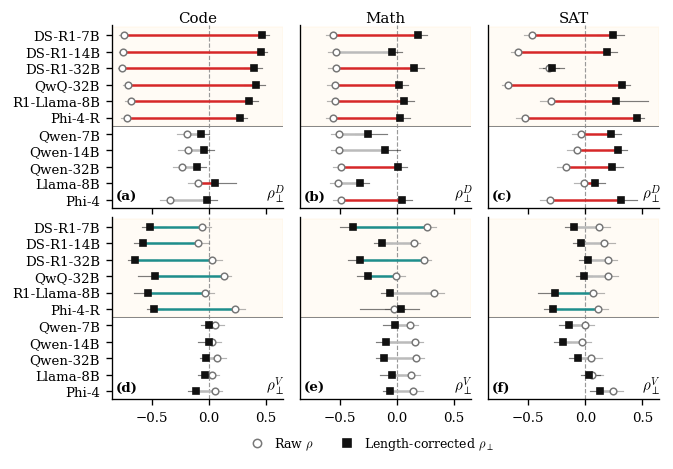

In [9]:
# ------- sign_reversal_combined: 2 rows (D, V) x 3 domains -------
fig = plt.figure(figsize=(5.5, 3.8))
gs = fig.add_gridspec(2, len(DOMAINS), wspace=0.10, hspace=0.05,
                      left=0.16, right=0.99, bottom=0.14, top=0.96)

XLIM_DV = (-0.85, 0.65)
panel_letters = [chr(ord('a') + i) for i in range(2 * len(DOMAINS))]
for col, _domain in enumerate(DOMAINS):
    ax_d = fig.add_subplot(gs[0, col])
    draw_dumbbell_panel(ax_d, 'D', _domain, values_df, XLIM_DV,
                        f"({panel_letters[col]})", DOMAIN_TITLE[_domain],
                        show_y=(col == 0), target_label=r"$\rho_\perp^D$")
    ax_d.set_xticks([-0.5, 0, 0.5])
    plt.setp(ax_d.get_xticklabels(), visible=False)
    ax_v = fig.add_subplot(gs[1, col])
    draw_dumbbell_panel(ax_v, 'V', _domain, values_df, XLIM_DV,
                        f"({panel_letters[len(DOMAINS) + col]})", "",
                        show_y=(col == 0), target_label=r"$\rho_\perp^V$")
    ax_v.set_xticks([-0.5, 0, 0.5])

legend_handles = [
    Line2D([0], [0], marker='o', mfc='white', mec=RAW_COLOR, mew=0.9, ms=5.0, ls='',
           label=r'Raw $\rho$'),
    Line2D([0], [0], marker='s', mfc=PERP_COLOR, mec=PERP_COLOR, ms=4.5, ls='',
           label=r'Length-corrected $\rho_\perp$'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.55, 0),
           ncol=2, frameon=False, columnspacing=1.6, handletextpad=0.4, fontsize=7.5)

fig.savefig(OUT_FIGS / 'sign_reversal_combined.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'sign_reversal_combined.png', dpi=300, bbox_inches='tight')
plt.show()


## Dimensionality signal (`dimensionality_signal.pdf`)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


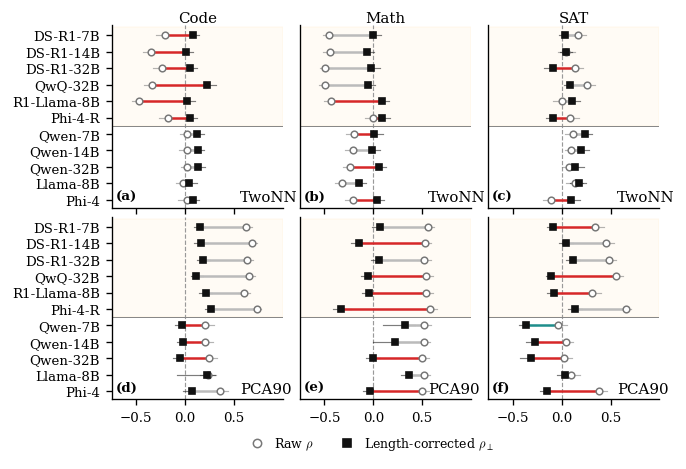

In [10]:
# ------- dimensionality_signal: 2 rows (TwoNN, PCA90) x 3 domains -------
XLIM_T_RAW = _xlim_metric(dim_values_df, 'T')
XLIM_P_RAW = _xlim_metric(dim_values_df, 'P')
XLIM_DIM = (min(XLIM_T_RAW[0], XLIM_P_RAW[0]), max(XLIM_T_RAW[1], XLIM_P_RAW[1]))

fig = plt.figure(figsize=(5.5, 3.8))
gs = fig.add_gridspec(2, len(DOMAINS), wspace=0.10, hspace=0.05,
                      left=0.16, right=0.99, bottom=0.14, top=0.96)

panel_letters = [chr(ord('a') + i) for i in range(2 * len(DOMAINS))]
for col, _domain in enumerate(DOMAINS):
    ax_t = fig.add_subplot(gs[0, col])
    draw_dim_panel(ax_t, 'T', _domain, dim_values_df, XLIM_DIM,
                   f"({panel_letters[col]})", DOMAIN_TITLE[_domain],
                   show_y=(col == 0), target_label="TwoNN")
    ax_t.set_xticks([-0.5, 0, 0.5])
    plt.setp(ax_t.get_xticklabels(), visible=False)
    ax_p = fig.add_subplot(gs[1, col])
    draw_dim_panel(ax_p, 'P', _domain, dim_values_df, XLIM_DIM,
                   f"({panel_letters[len(DOMAINS) + col]})", "",
                   show_y=(col == 0), target_label="PCA90")
    ax_p.set_xticks([-0.5, 0, 0.5])

legend_handles = [
    Line2D([0], [0], marker='o', mfc='white', mec=RAW_COLOR, mew=0.9, ms=5.0, ls='',
           label=r'Raw $\rho$'),
    Line2D([0], [0], marker='s', mfc=PERP_COLOR, mec=PERP_COLOR, ms=4.5, ls='',
           label=r'Length-corrected $\rho_\perp$'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.55, 0),
           ncol=2, frameon=False, columnspacing=1.6, handletextpad=0.4, fontsize=7.5)

fig.savefig(OUT_FIGS / 'dimensionality_signal.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'dimensionality_signal.png', dpi=300, bbox_inches='tight')
plt.show()


## Orthogonal length decomposition

Decomposes the raw correlation into the share explained by length (rho_parallel) and the residual (rho_perp).

In [11]:
df_dec = pd.read_parquet(DATA / '02_decomposition.parquet')
print(df_dec.sort_values(['domain', 'is_r1', 'model']).round(3).to_string(index=False))


              model domain  is_r1  rho_raw  rho_parallel  rho_perp  r2_length  n_problems
           llama-8b   code  False   -0.091        -0.208     0.051      0.436         500
              phi-4   code  False   -0.339        -0.338    -0.015      0.693         500
           qwen-14b   code  False   -0.183        -0.185    -0.042      0.878         500
           qwen-32b   code  False   -0.232        -0.227    -0.098      0.868         500
            qwen-7b   code  False   -0.192        -0.186    -0.069      0.896         500
    deepseek-r1-14b   code   True   -0.750        -0.702     0.456      0.814         500
    deepseek-r1-32b   code   True   -0.756        -0.706     0.401      0.800         500
     deepseek-r1-7b   code   True   -0.744        -0.709     0.465      0.833         500
    phi-4-reasoning   code   True   -0.719        -0.669     0.275      0.702         500
            qwq-32b   code   True   -0.704        -0.694     0.417      0.767         500
r1-distill

## Random-walk null

Length-driven trajectories reproduce raw directness ≈ −corr(difficulty, length) over a range of lengths and autocorrelations.

In [12]:
df_rw = pd.read_parquet(DATA / '02_random_walk.parquet')
print(df_rw.groupby(['N', 'rho'])['directness'].agg(['mean', 'std', 'count']).reset_index().head(20).to_string(index=False))


 N      rho     mean      std  count
20 0.000000 0.041079 0.034335    140
20 0.135714 0.039418 0.028082    140
20 0.271429 0.050819 0.038612    140
20 0.407143 0.048280 0.043815    140
20 0.542857 0.051396 0.042815    140
20 0.678571 0.068115 0.051949    140
20 0.814286 0.085525 0.066936    140
20 0.950000 0.136687 0.113482    140
40 0.000000 0.017252 0.013610    140
40 0.135714 0.020164 0.017323    140
40 0.271429 0.021180 0.016670    140
40 0.407143 0.023784 0.015973    140
40 0.542857 0.025812 0.019751    140
40 0.678571 0.034432 0.026686    140
40 0.814286 0.043303 0.034543    140
40 0.950000 0.083280 0.068499    140
80 0.000000 0.009478 0.007251    140
80 0.135714 0.010294 0.007842    140
80 0.271429 0.010445 0.007411    140
80 0.407143 0.012776 0.009443    140
